# bos-flow-vision: reproducing the headline results

This notebook reproduces the main results of the study in three tiers:

1. **Live computation** of the physics-based generator and its checks (M1) and a
   reduced displacement benchmark (M2).
2. **Re-scoring of committed predictions** from the trained segmentation models
   against committed reference ground truth (M3), with no images or model weights
   required.
3. **Committed experiment tables** for the controlled experiments (M4), plus a live
   illustration of the label-integrity failure mode.

It runs in a few minutes on a laptop CPU. Commands for a full regeneration from
seeds (datasets, training, evaluation) are listed at the end.

In [1]:
import csv, json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RES = ROOT / "results"
import sys
sys.path.insert(0, str(ROOT / "scripts"))

from bosflow import generate as G, labels
from bosflow.analysis import physics_check as P
from bosflow.optics.camera import Camera
from bosflow.optics.deflection import Optics
from bosflow.physics import fields as F, gasdynamics as gd
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
print("repository:", ROOT)

repository: /Users/terryzhou/Documents/_personal/bos-flow-vision


## M1. Physics-based synthetic BOS

A Mach 2.5 flow over a 10 degree wedge is rendered through the BOS optical model
(line-of-sight integration, Gladstone-Dale deflection, aperture smearing, dot-pattern
warp, sensor noise). The shock angle measured from the rendered ground-truth
displacement is compared with the theta-beta-Mach relation, and the freestream Mach
number is recovered by inverting that relation.

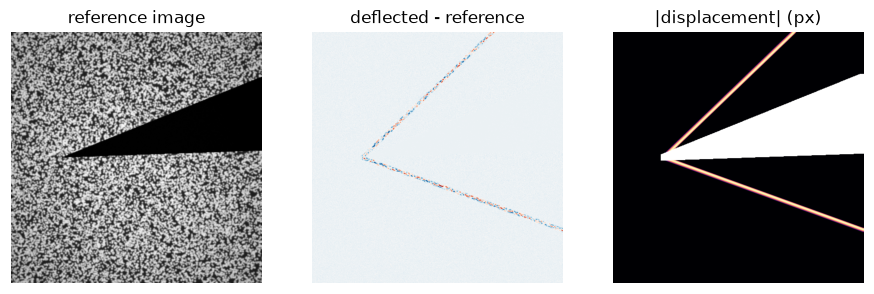

| shock | measured beta (deg) | theory beta (deg) | recovered Mach (true 2.5) |
|---|---:|---:|---:|
| upper | 31.818 | 31.851 | 2.5029 |
| lower | 31.840 | 31.851 | 2.5010 |

In [2]:
optics = Optics()
fov = optics.field_of_view[1]
flow = F.WedgeFlow(2.5, np.radians(10.0), 0.05, 0.15, F.Pose(-0.3 * fov, 0.0, np.radians(12.0)))
s = G.render(flow, optics, Camera(), {"dot_density": 0.08, "dot_diameter_px": 2.5},
             np.random.default_rng(0))
mag = np.hypot(*s.flow)

beta_true = np.degrees(flow.shock.beta)
rows = []
for inst in s.instances:
    beta = P.mask_shock_angle(inst.mask & s.valid, 12.0, weight=mag**2)
    rows.append((inst.attrs["side"], beta, P.mach_from_wedge_shock(beta, 10.0)))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
ax[0].imshow(s.reference, cmap="gray"); ax[0].set_title("reference image")
ax[1].imshow(s.deflected.astype(float) - s.reference, cmap="RdBu_r"); ax[1].set_title("deflected - reference")
ax[2].imshow(np.where(s.valid, mag, np.nan), cmap="magma"); ax[2].set_title("|displacement| (px)")
for a in ax: a.axis("off")
plt.show()
display(Markdown("| shock | measured beta (deg) | theory beta (deg) | recovered Mach (true 2.5) |\n|---|---:|---:|---:|\n"
                 + "\n".join(f"| {side} | {b:.3f} | {beta_true:.3f} | {m:.4f} |" for side, b, m in rows)))

A spherical blast front follows the Sedov-Taylor law R = xi0 (E t^2 / rho0)^(1/5).
The generator's similarity solution reproduces the classical constant xi0 = 1.033 for
gamma = 1.4, and fitting R(t) recovers the exponent 2/5 and the released energy.

In [3]:
sol = gd.sedov_taylor(1.4)
E, rho0 = 250.0, 0.1
t = np.linspace(2e-5, 1e-4, 8)
R = sol.radius(E, rho0, t)
n, _ = P.power_law_fit(t, R)
print(f"xi0 = {sol.xi0:.4f} (Sedov and Taylor: 1.033)")
print(f"fitted exponent = {n:.6f} (theory 0.4), recovered energy = {P.sedov_energy(t, R, rho0):.3f} J (true {E} J)")

xi0 = 1.0328 (Sedov and Taylor: 1.033)
fitted exponent = 0.400000 (theory 0.4), recovered energy = 250.000 J (true 250.0 J)


## M2. Displacement estimation

Six dense estimators were scored on 100 scenes at four noise levels
(`results/m2/records.csv`). The table reports endpoint error inside labeled flow
features and the fraction of the true peak displacement recovered.

| method | EPE all (medium) | EPE in features (medium) | peak recovery (medium) |
|---|---:|---:|---:|
| farneback | 0.043 | 0.178 | 0.74 |
| lucas_kanade | 0.035 | 0.234 | 0.60 |
| dis | 0.029 | 0.176 | 0.68 |
| tvl1 | 0.064 | 0.190 | 0.69 |
| demons | 0.100 | 0.182 | 0.82 |
| raft | 0.049 | 0.510 | 0.10 |

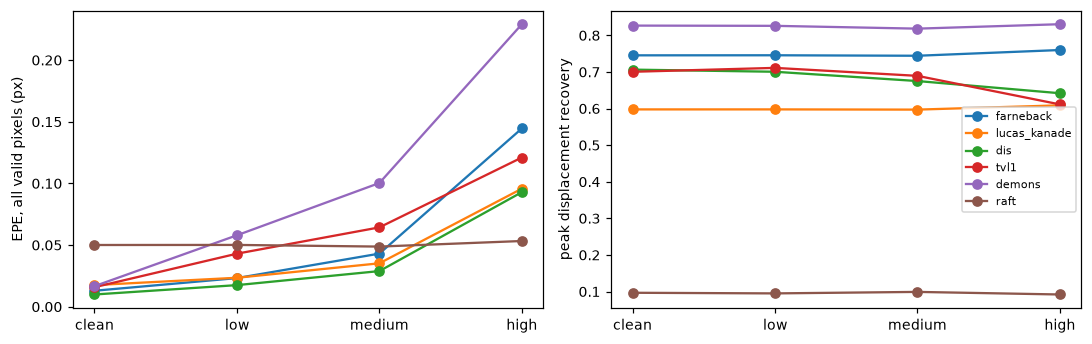

In [4]:
recs = list(csv.DictReader(open(RES / "m2" / "records.csv")))
methods = list(dict.fromkeys(r["method"] for r in recs))
levels = ["clean", "low", "medium", "high"]
mean = lambda m, lv, k: np.mean([float(r[k]) for r in recs if r["method"] == m and r["noise"] == lv and r.get(k)])
lines = ["| method | EPE all (medium) | EPE in features (medium) | peak recovery (medium) |", "|---|---:|---:|---:|"]
lines += [f"| {m} | {mean(m, 'medium', 'epe'):.3f} | {mean(m, 'medium', 'epe_feature'):.3f} | {mean(m, 'medium', 'peak_ratio'):.2f} |" for m in methods]
display(Markdown("\n".join(lines)))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for m in methods:
    ax[0].plot(levels, [mean(m, lv, "epe") for lv in levels], marker="o", label=m)
    ax[1].plot(levels, [mean(m, lv, "peak_ratio") for lv in levels], marker="o", label=m)
ax[0].set_ylabel("EPE, all valid pixels (px)"); ax[1].set_ylabel("peak displacement recovery")
ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()

A reduced live rerun (one scene per flow type, three fast estimators) confirms the
ordering on this machine.

In [5]:
from bosflow.displacement import benchmark as B
bcfg = B.load_benchmark_config()
bcfg["noise_levels"] = {k: bcfg["noise_levels"][k] for k in ("clean", "medium")}
live = B.run(bcfg, G.load_config(), scenes_per_type=1, methods=["dis", "farneback", "demons"],
             progress=lambda *_: None)
for m in ("dis", "farneback", "demons"):
    e = [r["epe"] for r in live if r["method"] == m and r["noise"] == "medium"]
    p = [r["peak_ratio"] for r in live if r["method"] == m and r["noise"] == "medium" and "peak_ratio" in r]
    print(f"{m:10s} EPE {np.mean(e):.3f} px, peak recovery {np.mean(p):.2f}")

dis        EPE 0.027 px, peak recovery 0.61
farneback  EPE 0.043 px, peak recovery 0.68
demons     EPE 0.098 px, peak recovery 0.78


## M3. Segmentation and physics from predicted masks

Committed predictions of the two RF-DETR Seg Medium models (trained locally and on the
hosted platform) are re-scored against the committed reference ground truth: mask mAP
on the 100-image test split, Mach number recovered from predicted shock masks, and
blast energy from fronts tracked through 20 sequences.

In [6]:
from m4_physics import blast_tracks, mask_map, shock_mach
ref = RES / "reference"
lines = ["| model | mask mAP50-95 | shock | fan | shear | wedge Mach err | cone Mach err | blast exponent (gated) | worst E err (gated) |",
         "|---|---:|---:|---:|---:|---:|---:|---:|---:|"]
for model in ("local", "hosted"):
    pred = json.load(open(RES / "m4" / model / "predictions_test.json"))
    mm = mask_map(ref / "v1_test", pred)
    mach = shock_mach(ref / "v1_test", pred, 0.5)
    med = lambda ft: np.median([abs(r["M_pred"] / r["M_true"] - 1) for r in mach if r["flow_type"] == ft])
    b = blast_tracks(ref / "sequences", json.load(open(RES / "m4" / model / "predictions_sequences.json")))
    g = [x["gated"] for x in b if "exponent" in x["gated"]]
    pc = mm["per_class"]
    lines.append(f"| {model} | {mm['mAP50_95']:.3f} | {pc['shock']['AP50_95']:.3f} | {pc['expansion_fan']['AP50_95']:.3f} | "
                 f"{pc['shear_layer']['AP50_95']:.3f} | {100 * med('wedge'):.1f}% | {100 * med('cone'):.1f}% | "
                 f"{np.mean([x['exponent'] for x in g]):.4f} | {100 * max(abs(x['E_rel_err']) for x in g):.1f}% |")
display(Markdown("\n".join(lines)))

| model | mask mAP50-95 | shock | fan | shear | wedge Mach err | cone Mach err | blast exponent (gated) | worst E err (gated) |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| local | 0.826 | 0.573 | 0.977 | 0.928 | 0.2% | 1.9% | 0.3989 | 2.8% |
| hosted | 0.840 | 0.618 | 0.989 | 0.912 | 0.1% | 1.9% | 0.3990 | 2.4% |

## M4. Controlled experiments

Single-variable training arms (recipe, data, input encoding, label source) were scored
on the test split, the blast sequences, and seven held-out stress sets. The table
below is read from `results/m4_experiments/tables.json`.

In [7]:
T = json.load(open(RES / "m4_experiments" / "tables.json"))
names = {"m3_local": "M3 local", "arm_A_hosted_recipe": "A: hosted recipe", "arm_B_v2_data": "B: v2 data",
         "arm_C_vec_encoding": "C: vector encoding", "arm_D_platform_labels": "D: platform labels",
         "v2_hosted": "v2 hosted"}
sets = ["v1_test", "control", "estimator_farneback", "estimator_demons", "camera_harsh",
        "optics_shift", "physics_extrapolation", "composite"]
lines = ["| model | labels | blast sequences failing | " + " | ".join(sets) + " |", "|---|---|---:|" + "---:|" * len(sets)]
for key, lab in names.items():
    row = T.get(key, {})
    raw = row.get("blast", {}).get("raw", {})
    src = "platform" if key in ("arm_D_platform_labels", "v2_hosted") else "local"
    lines.append(f"| {lab} | {src} | {raw.get('n_bad', 'n/a')}/{raw.get('n', 'n/a')} | "
                 + " | ".join(f"{row[s]['mAP50_95']:.3f}" if s in row else "n/a" for s in sets) + " |")
display(Markdown("\n".join(lines)))

| model | labels | blast sequences failing | v1_test | control | estimator_farneback | estimator_demons | camera_harsh | optics_shift | physics_extrapolation | composite |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| M3 local | local | 0/20 | 0.826 | 0.846 | 0.786 | 0.730 | 0.609 | 0.770 | 0.654 | 0.421 |
| A: hosted recipe | local | 0/20 | 0.783 | 0.814 | 0.764 | 0.681 | 0.610 | 0.701 | 0.605 | 0.429 |
| B: v2 data | local | 0/20 | 0.822 | 0.843 | 0.789 | 0.720 | 0.575 | 0.760 | 0.683 | 0.450 |
| C: vector encoding | local | 0/20 | 0.817 | 0.840 | 0.754 | 0.652 | 0.618 | 0.748 | 0.685 | 0.474 |
| D: platform labels | platform | 2/20 | 0.800 | 0.840 | 0.784 | 0.692 | 0.570 | 0.767 | 0.672 | 0.434 |
| v2 hosted | platform | 7/20 | 0.841 | 0.862 | 0.740 | 0.580 | 0.608 | 0.739 | 0.620 | 0.368 |

### The label-integrity failure mode

A blast front clipped by the image boundary can split into several arcs. As a COCO
annotation this is a list of polygons. A store that keeps one polygon per instance and
concatenates the list turns the arcs into one filled region, which is what the hosted
models learned from. Exporting each piece as its own annotation avoids it.

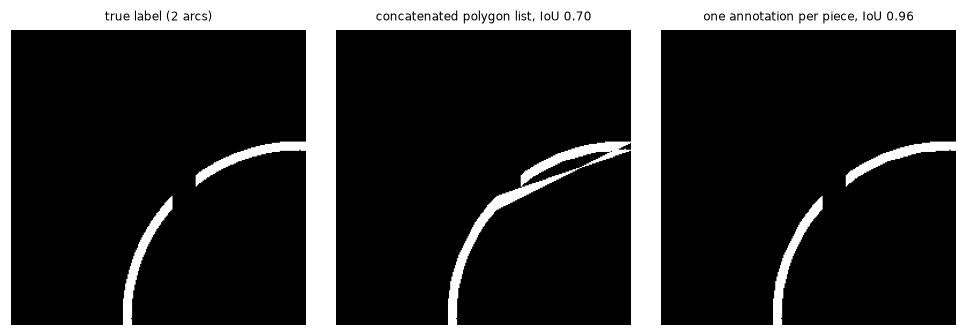

In [8]:
import cv2
yy, xx = np.mgrid[0:256, 0:256]
mask = np.abs(np.hypot(xx - 250, yy - 250) - 150.0) < 4.0
mask[:, 140:160] = False
multi = labels.mask_to_polygons(mask)
concatenated = labels.polygons_to_mask([sum(multi, [])], mask.shape)
pieces = labels.instance_annotations(1, 1, "shock", mask)
per_piece = labels.polygons_to_mask([a["segmentation"][0] for a in pieces], mask.shape)
iou = lambda a: (a & mask).sum() / (a | mask).sum()
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for a, img, title in zip(ax, (mask, concatenated, per_piece),
                         ("true label (2 arcs)", f"concatenated polygon list, IoU {iou(concatenated):.2f}",
                          f"one annotation per piece, IoU {iou(per_piece):.2f}")):
    a.imshow(img, cmap="gray"); a.set_title(title, fontsize=8); a.axis("off")
plt.tight_layout(); plt.show()

## Qualitative zero-shot on NASA AirBOS imagery

Published NASA AirBOS 4 images (NASA Ames; used for illustration only, no NASA
endorsement implied) converted to a displacement-magnitude proxy. Left: model input.
Right: predicted masks.

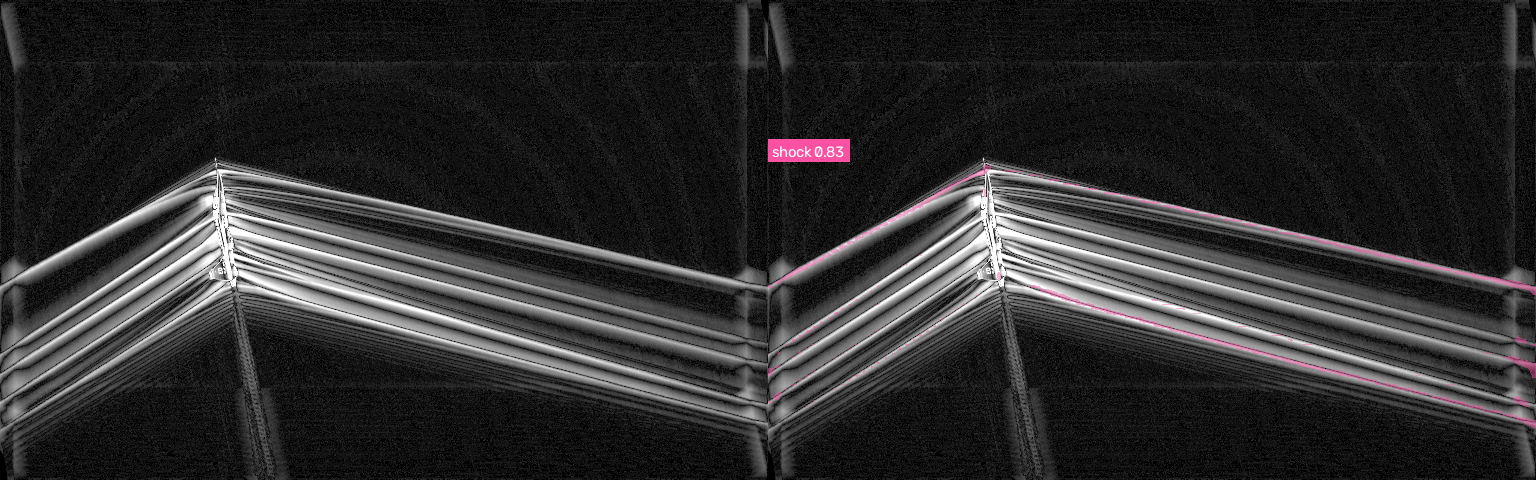

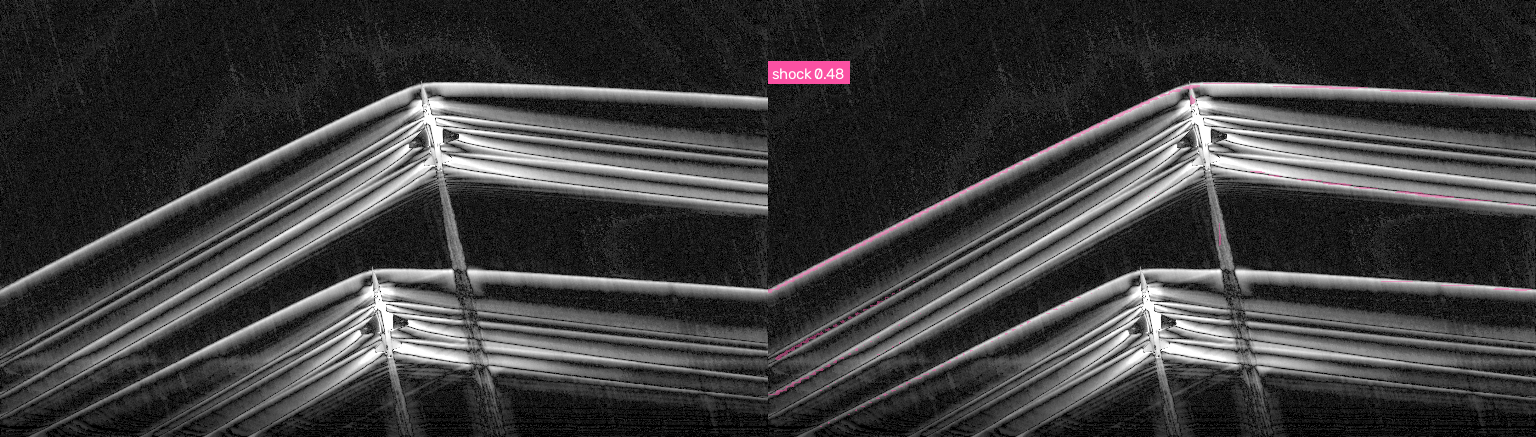

In [9]:
for f in sorted((RES / "m4_experiments" / "nasa").glob("*_zero_shot.png"))[:2]:
    display(Image(filename=str(f), width=900))

## Full regeneration

Every dataset is seeded and byte-reproducible. From a clean checkout:

```
uv sync --group train
uv run python scripts/generate_dataset.py --sequences --out data/synthetic/v1
uv run python scripts/benchmark_displacement.py --out results/m2
uv run python scripts/build_rf_dataset.py --dataset data/synthetic/v1 --estimator dis --out data/synthetic/v1_rf_dis
uv run python scripts/train_local.py --data data/synthetic/v1_rf_dis --size medium --epochs 40
uv run python scripts/build_stress_sets.py --out data/synthetic/stress
uv run python scripts/evaluate_suite.py --models m3_local --sequences
uv run python scripts/m4_tables.py
```

Training takes about two hours per model on an Apple M5 Pro GPU.